<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_Ensemble_voting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/placement.csv")

In [ ]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,2]

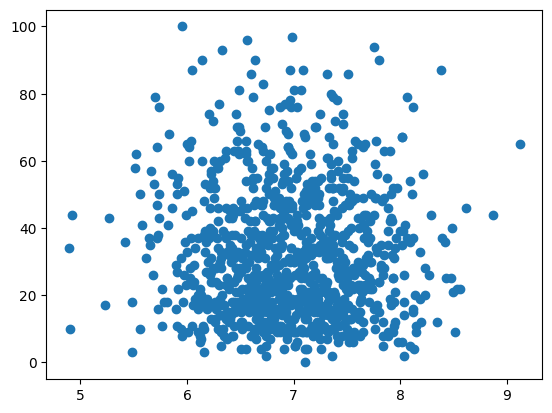

In [ ]:
plt.scatter(df['cgpa'],df['placement_exam_marks'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X_test.shape

(200, 2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = DecisionTreeClassifier()

In [ ]:
estimators = [('lr',clf1),('knn',clf2),('DT',clf3)]

In [ ]:
import numpy as np

In [ ]:
from sklearn.model_selection import cross_val_score
for estimator in estimators:
  x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
  print(estimator[0],np.round(np.mean(x),2))



lr 0.5
knn 0.49
DT 0.51


In [ ]:
from sklearn.ensemble import VotingClassifier


Hard voting

In [ ]:
vc = VotingClassifier(estimators = estimators,voting='hard')

In [ ]:
vc.fit(X_train,y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('knn', KNeighborsClassifier()),
                             ('DT', DecisionTreeClassifier())])

In [ ]:
y_pre = vc.predict(X_test)

In [ ]:
p = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
np.round(np.mean(p),2)

0.49

Soft voting

In [ ]:
vc_s = VotingClassifier(estimators = estimators,voting='soft')

In [ ]:
q = cross_val_score(vc_s,X,y,cv=10,scoring='accuracy')
np.round(np.mean(q),2)

0.5